Importing required libraries.

In [3]:
!pip install langdetect
!pip install googletrans==3.1.0a0

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 16.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for langdetect: filename=langdetect-1.0.9-py3-none-any.whl size=993223 sha256=81718cc4f6fe7521fcebe288e415acad6da7c7fb7b11409e66468437bb7032d4
  Stored in directory: /root/.cache/pip/wheels/0a/f2/b2/e5ca405801e05eb7c8ed5b3b4bcf1fcabcd6272c167640072e
Successfully built langdetect
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.1/55.1 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 133.4/133.4 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.6/42.6 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.8/58.8 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.0/65.0 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 32.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.6/53.6 kB 3.0 MB/s eta 0:

In [4]:
#Importing Panda for Basic Operation
import pandas as pd
#Importing Matplotlib and Seasborn for Various Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Loading the data

In [23]:
df_train = pd.read_csv('/content/train.csv')
df_test = pd.read_csv('/content/test.csv')
test_labels = pd.read_csv('/content/test_labels.csv')
df_val = pd.read_csv('/content/validation.csv')

# Data Clean and EDA

Basic info of the dataset

In [9]:
print("First rows of TrainSet....")
df_train.head()

First rows of TrainSet....


,id,feedback_text,toxic,abusive,vulgar,menace,offense,bigotry
0,281d77b7bebc2201,:::Sounds good. Let me know when you're done ...,0,0,0,0,0,0
1,716aac7bf3c63db1,"""\nI say something, but it didn't actually con...",0,0,0,0,0,0
2,57cb318c6edcf10c,"""Agustina Barrientos]] \n | Modelo de Piñeiro ...",0,0,0,0,0,0
3,dc3bd70118d91b3a,FYI I enjoy licking strangers scrotal sacks......,1,0,1,0,0,0
4,cf10d41f2997d233,How do you get a site?\nMany penguins have ask...,0,0,0,0,0,0


In [47]:
print("number of Rows and Columns of TrainSet...")
df_train.shape

number of Rows and Columns of TrainSet...


(23473, 8)

In [48]:
print("Dataframe Information on TrainSet...")
df_train.info()

Dataframe Information on TrainSet...
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23473 entries, 0 to 23472
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   id             23473 non-null  object
 1   feedback_text  23473 non-null  object
 2   toxic          23473 non-null  int64 
 3   abusive        23473 non-null  int64 
 4   vulgar         23473 non-null  int64 
 5   menace         23473 non-null  int64 
 6   offense        23473 non-null  int64 
 7   bigotry        23473 non-null  int64 
dtypes: int64(6), object(2)
memory usage: 1.4+ MB


In [8]:
#checking for any duplicated rows
df_train.duplicated().sum()

np.int64(0)

In [49]:
# Check for missing values
print(df_train.isnull().sum())

id               0
feedback_text    0
toxic            0
abusive          0
vulgar           0
menace           0
offense          0
bigotry          0
dtype: int64


In [50]:
# toxic vs non toxic values in the dataset
df_train['toxic'].value_counts()

,count
toxic,
0,21277
1,2196


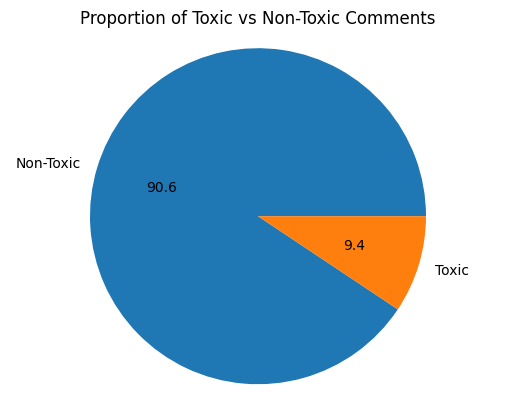

In [51]:
# pychart for better representation
plt.pie(df_train['toxic'].value_counts(), labels=['Non-Toxic', 'Toxic'], autopct='%0.1f')
plt.title('Proportion of Toxic vs Non-Toxic Comments')
plt.axis('equal')
plt.show()

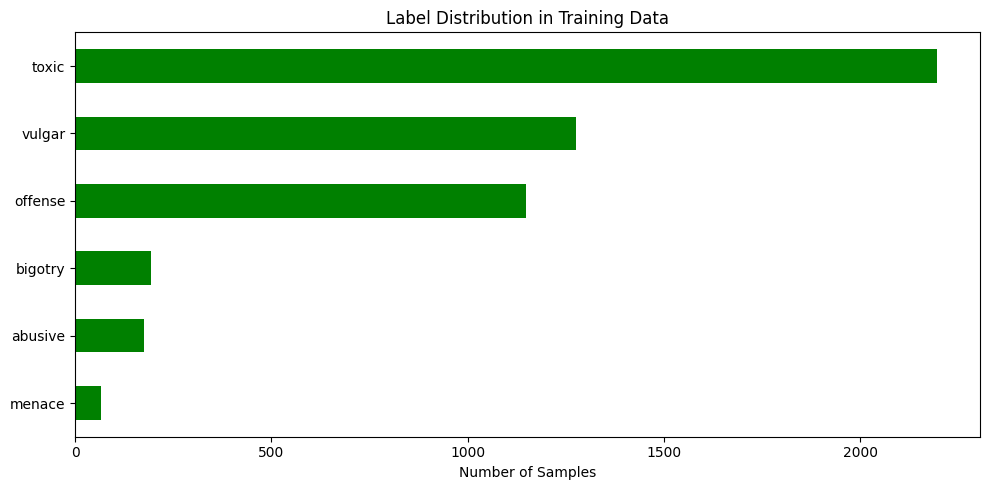

In [52]:
#bar chart for visualizing label distribution
labels = ['toxic', 'abusive', 'vulgar', 'menace', 'offense', 'bigotry']
label_counts = df_train[labels].sum()
plt.figure(figsize=(10, 5))
label_counts.sort_values().plot(kind="barh", color='green')
plt.title("Label Distribution in Training Data")
plt.xlabel("Number of Samples")
plt.tight_layout()
plt.show()


The data is imbalanced

Undersampling the data as it is imbalanced

In [10]:
from sklearn.utils import resample

#Separating majority (non-toxic) and minority (toxic)
df_majority = df_train[df_train['toxic'] == 0]
df_minority = df_train[df_train['toxic'] == 1]

#Downsample the majority class
df_majority_downsampled = resample(
    df_majority,
    replace=False,
    n_samples=len(df_minority),
    random_state=42
)

#Combining minority and downsampled majority
df_undersampled = pd.concat([df_minority, df_majority_downsampled])

#Shuffle the combined data
df_undersampled = df_undersampled.sample(frac=1, random_state=42).reset_index(drop=True)

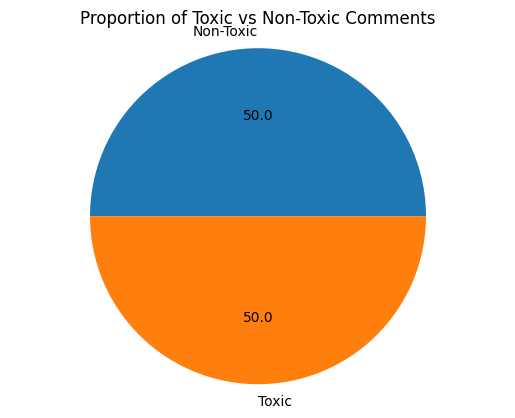

In [55]:
#After undersampling
plt.pie(df_undersampled['toxic'].value_counts(), labels=['Non-Toxic', 'Toxic'], autopct='%0.1f')
plt.title('Proportion of Toxic vs Non-Toxic Comments')
plt.axis('equal')
plt.show()

In [13]:
pip install nltk

In [11]:
import nltk
nltk.download('punkt_tab')
#fetching the number of words and sentences from the feedback_text column
df_undersampled['words'] = df_undersampled['feedback_text'].apply(lambda x: len(nltk.word_tokenize(x)))
df_undersampled['sentences'] = df_undersampled['feedback_text'].apply(lambda x: len(nltk.sent_tokenize(x)))

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


In [59]:
# Display descriptive statistics of words and sentences from the feedback_text
df_undersampled[['words', 'sentences']].describe()

,words,sentences
count,4392.000000,4392.000000
mean,73.463570,4.314663
std,144.770019,9.293650
min,2.000000,1.000000
25%,16.000000,1.000000
50%,34.000000,3.000000
75%,74.000000,5.000000
max,4849.000000,242.000000


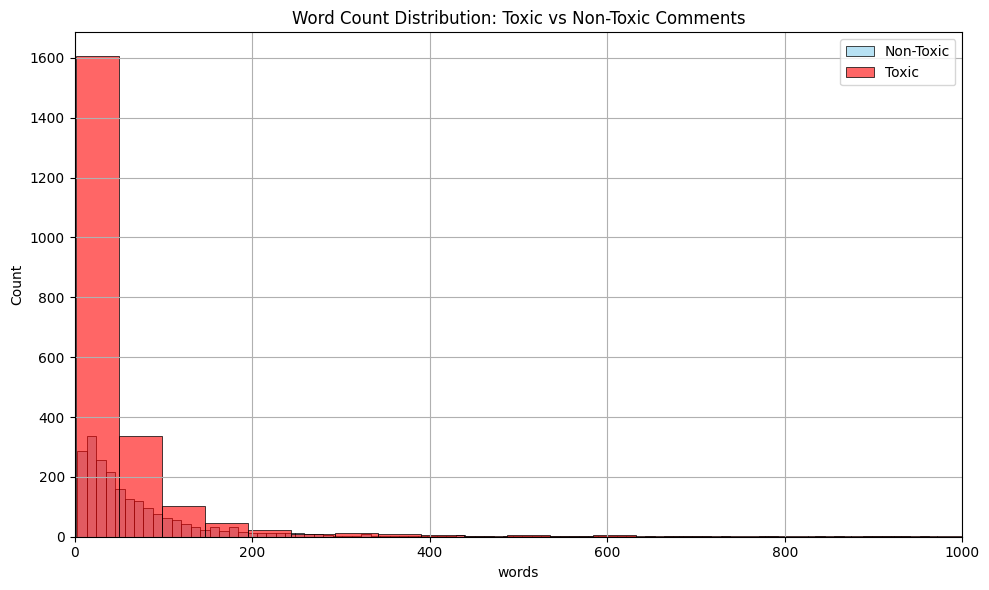

In [12]:
#Word count histogram for toxic and non-toxic comments
plt.figure(figsize=(10, 6))

sns.histplot(df_undersampled[df_undersampled['toxic'] == 0]['words'],
             color='skyblue',
             label='Non-Toxic',
             bins=100,
             alpha=0.6)

sns.histplot(df_undersampled[df_undersampled['toxic'] == 1]['words'],
             color='red',
             label='Toxic',
             bins=100,
             alpha=0.6)

plt.xlim(0, 1000)  # Adjust as needed
plt.title('Word Count Distribution: Toxic vs Non-Toxic Comments')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


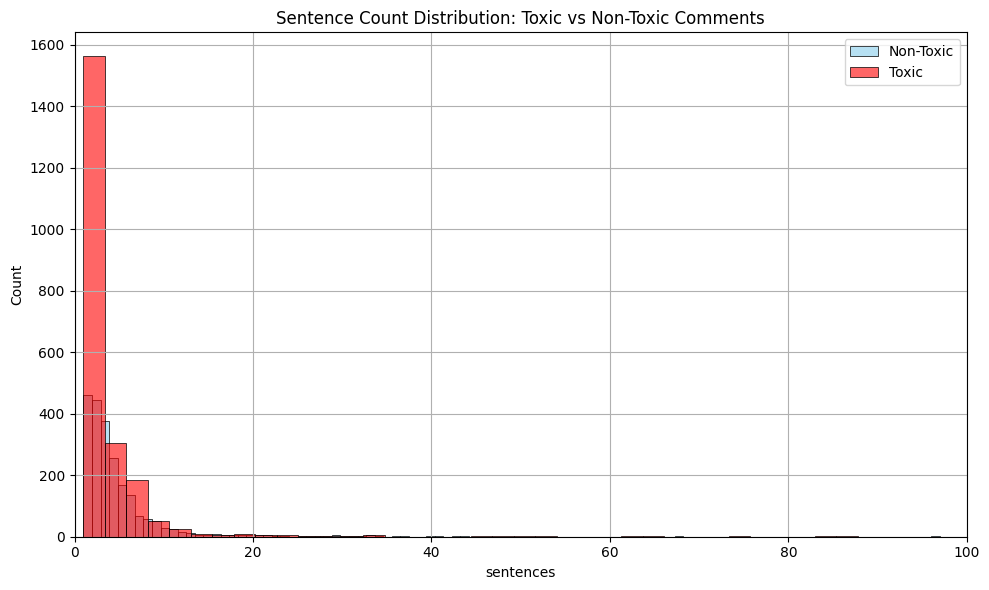

In [61]:
#Sentence count histogram for toxic and non-toxic comments
plt.figure(figsize=(10, 6))

sns.histplot(df_undersampled[df_undersampled['toxic'] == 0]['sentences'],
             color='skyblue',
             label='Non-Toxic',
             bins=100,
             alpha=0.6)

sns.histplot(df_undersampled[df_undersampled['toxic'] == 1]['sentences'],
             color='red',
             label='Toxic',
             bins=100,
             alpha=0.6)

plt.xlim(0, 100)  # Adjust as needed
plt.title('Sentence Count Distribution: Toxic vs Non-Toxic Comments')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

<Axes: >

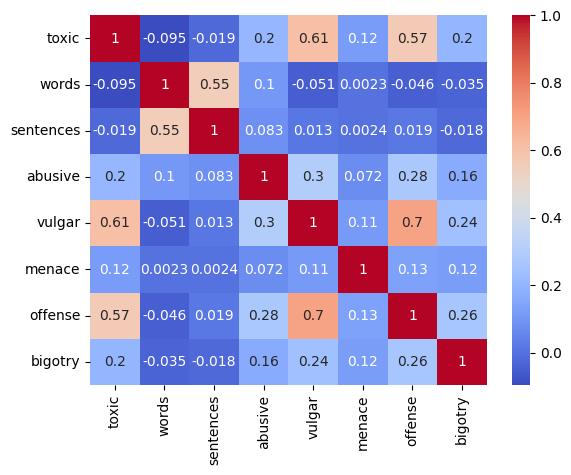

In [62]:
#visualizing correlation between words and sentences
numerical_features = ['toxic','words', 'sentences',  'abusive', 'vulgar', 'menace', 'offense', 'bigotry']
sns.heatmap(df_undersampled[numerical_features].corr(), annot=True, cmap='coolwarm')

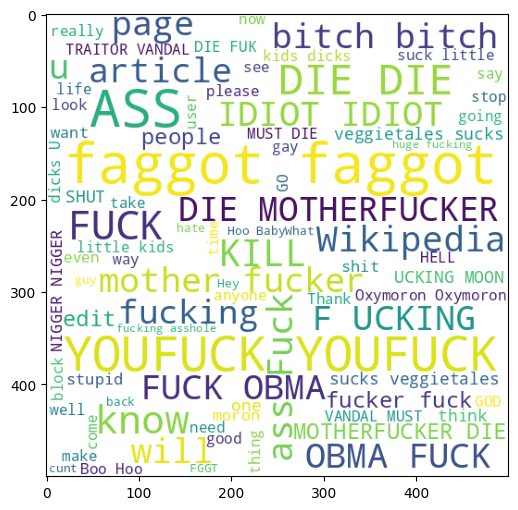

In [63]:
#Visualing common words when toxic=1
from wordcloud import WordCloud
wc = WordCloud(width=500,height=500,min_font_size=10,background_color='white')
tox = wc.generate(df_undersampled[df_undersampled['toxic'] == 1]['feedback_text'].str.cat(sep=" "))
plt.figure(figsize=(15,6))
plt.imshow(tox)

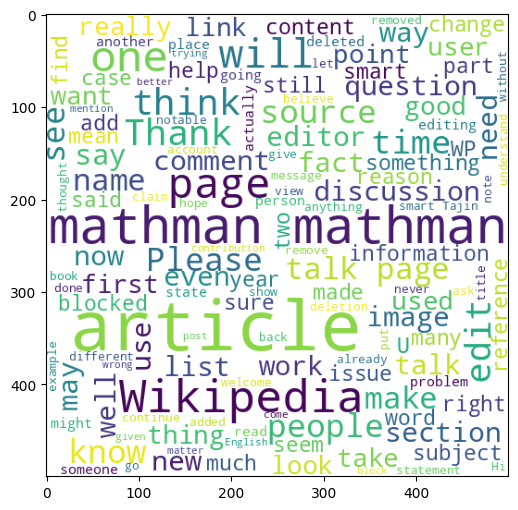

In [64]:
#Visualing common words when toxic=0
wc = WordCloud(width=500,height=500,min_font_size=10,background_color='white')
tox = wc.generate(df_undersampled[df_undersampled['toxic'] == 0]['feedback_text'].str.cat(sep=" "))
plt.figure(figsize=(15,6))
plt.imshow(tox)

# Text Preprocessing

In [13]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer


nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

def clean_text(text):
    # Convert to lowercase
    text = text.lower()
    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    # Remove user mentions and hashtags
    text = re.sub(r'\@\w+|\#', '', text)
    # Remove special characters and numbers
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Remove stopwords. Also tokenize and lemmatize
def lemmatize_text(text):
    lemmatizer = WordNetLemmatizer()
    stop_words = set(stopwords.words('english'))
    words = nltk.word_tokenize(text)
    words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]
    return ' '.join(words)

# Apply cleaning
df_undersampled['cleaned_text'] = df_undersampled['feedback_text'].apply(clean_text)
df_undersampled['cleaned_text'] = df_undersampled['cleaned_text'].apply(lemmatize_text)


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


In [98]:
df_undersampled.head()

,id,feedback_text,toxic,abusive,vulgar,menace,offense,bigotry,words,sentences,cleaned_text
0,5be443f4df288604,:::Yeah. The map looks good though. Thank you.,0,0,0,0,0,0,14,3,yeah map look good though thank
1,2046f2db4e95369b,January 2011 (UTC) \n :::::::Besides an al-Qae...,0,0,0,0,0,0,121,4,january utc besides alqaeda comparison astonis...
2,22bf8ec5e5c19c8a,Your a moron everything is on the articles th...,1,0,0,0,0,0,45,3,moron everything article page yeah one actuall...
3,edf27b8f110d2700,"You son of a bitch! You did it again, readers ...",1,0,1,0,1,0,45,4,son bitch reader might wan na know shit would ...
4,2100c7daaa16ba6d,"""I know about there being kickabouts on the we...",0,0,0,0,0,0,235,14,know kickabouts weekend shall miss daily routi...


# Model building (Baseline)

Logistic Regression

In [20]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.multioutput import MultiOutputClassifier

# Feature extraction
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_train = tfidf.fit_transform(df_undersampled['cleaned_text'])

# Train on all labels
logreg = MultiOutputClassifier(
    LogisticRegression(class_weight='balanced', max_iter=1000),
    n_jobs=-1
)
logreg.fit(X_train, df_undersampled[['toxic', 'abusive', 'vulgar', 'menace', 'offense', 'bigotry']])

# Extract only the toxic classifier
toxic_logreg = logreg.estimators_[0]

In [25]:
from langdetect import detect
from googletrans import Translator
import numpy as np

translator = Translator()

def safe_translate(text):
    try:
        lang = detect(text)
        if lang != 'en':
            return translator.translate(text, dest='en').text
    except:
        pass
    return text  # Fallback to original text

# Translate a list of test texts
df_val['translated_text'] = df_val['feedback_text'].apply(safe_translate)

# Transform with TF-IDF
X_test = tfidf.transform(df_val['translated_text'])

# Predict with your trained model
y_preds = toxic_logreg.predict(X_test)


In [127]:
df_val.head()

,id,feedback_text,lang,toxic,translated_text
0,1203,İyi tamam olabilir. Balkanlar maddesini gelişt...,tr,0,Well okay. We improve the Balkans substance an...
1,5871,"Por dios, y la canción de John Lennon: http://...",es,1,"By God, and John Lennon's song: http://www.you..."
2,3590,Selam. Öncelikle tebrik ederim... Bu arada ken...,tr,0,"Hi. First of all, I congratulate you ... In th..."
3,447,Leggiti tutte le discussioni. Magari cancellal...,it,1,Read all the discussions. Maybe delete and get...
4,6634,A LAS TOKITAS NOS VALE QUE LAS JONATICAS INSUL...,es,1,A LAS TOKITAS NOS VALE QUE LAS JONATICAS INSUL...


In [28]:
y_true = df_val['toxic'].values

In [69]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, roc_curve
def evaluate_model(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_pred)

    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1 Score : {f1:.4f}")
    print(f"AUC-ROC  : {auc:.4f}\n")

In [75]:
evaluate_model(y_true, y_preds)

Accuracy : 0.7952
Precision: 0.3967
Recall   : 0.5448
F1 Score : 0.4591
AUC-ROC  : 0.6938



Random Forest

In [72]:
from sklearn.ensemble import RandomForestClassifier

# Train on all labels using Random Forest
rf = MultiOutputClassifier(
    RandomForestClassifier(
        class_weight='balanced',  # Note: RandomForest has different class_weight options
        n_estimators=100,        # Number of trees in the forest
        max_depth=None,          # Maximum depth of the tree
        min_samples_split=2,     # Minimum number of samples required to split a node
        random_state=42,         # For reproducibility
        n_jobs=-1               # Use all processors
    ),
    n_jobs=-1
)
rf.fit(X_train, df_undersampled[['toxic', 'abusive', 'vulgar', 'menace', 'offense', 'bigotry']])

# Extract only the toxic classifier
toxic_rf = rf.estimators_[0]

In [73]:
# Predict with your trained model
y_rfpreds = toxic_rf.predict(X_test)

In [74]:
evaluate_model(y_true, y_rfpreds)

Accuracy : 0.7405
Precision: 0.2375
Recall   : 0.2836
F1 Score : 0.2585
AUC-ROC  : 0.5554



#  LSTM

In [14]:
!pip install keras

In [29]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Embedding, LSTM, Dense, Dropout, Bidirectional, Attention
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import numpy as np

# Tokenization and sequence preparation
tokenizer = Tokenizer(num_words=5000, oov_token="<OOV>")
tokenizer.fit_on_texts(df_undersampled['cleaned_text'])

# Convert text to sequences
X_seq = tokenizer.texts_to_sequences(df_undersampled['cleaned_text'])
X_pad = pad_sequences(X_seq, maxlen=200, padding='post', truncating='post')

X_val_seq = tokenizer.texts_to_sequences(df_val['translated_text'])
X_val_pad = pad_sequences(X_val_seq, maxlen=200, padding='post')

# True labels
y_true = df_val['toxic'].values

# Prepare all labels for training
y_train_all = df_undersampled[['toxic', 'abusive', 'vulgar', 'menace', 'offense', 'bigotry']].values


In [30]:
# Model Architecture
inputs = Input(shape=(200,))  # Same as your sequence length

# 2. Embedding Layer
embed = Embedding(input_dim=5000,  # Vocabulary size
                 output_dim=128,   # Embedding dimension
                 input_length=200)(inputs)

# 3. Bidirectional LSTM (with return_sequences=True for Attention)
lstm = Bidirectional(LSTM(64, return_sequences=True))(embed)

# 4. Attention Layer (Key Change!)
att = Attention()([lstm, lstm])  # Self-attention on LSTM outputs

# 5. Global Average Pooling (Recommended for Attention outputs)
from tensorflow.keras.layers import GlobalAveragePooling1D
att_pooled = GlobalAveragePooling1D()(att)

# 6. Dense Layers
dense1 = Dense(64, activation='relu')(att_pooled)
outputs = Dense(1, activation='sigmoid')(dense1)  # Toxic probability

# 7. Compile Model
model = Model(inputs=inputs, outputs=outputs)
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

# Model summary
model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 200)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_2         │ (None, 200, 128)  │    640,000 │ input_layer_2[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_2     │ (None, 200, 128)  │     98,816 │ embedding_2[0][0] │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_1         │ (None, 200, 128)  │          0 │ bidirectional_2[… │
│ (Attention)         │                   │            │ bidirectional_2[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ attention_1[0][0] │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 64)        │      8,256 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 1)         │         65 │ dense_2[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 747,137 (2.85 MB)

 Trainable params: 747,137 (2.85 MB)

 Non-trainable params: 0 (0.00 B)

In [32]:
# 4. Train using toxic labels only (but model sees all labels during forward pass)
model.fit(
    X_pad,
    df_undersampled['toxic'].values,
    batch_size=64,
    epochs=10,
    validation_data=(X_val_pad, y_true),  # From your validation set
    class_weight={0: 1, 1: 5}
)

Epoch 1/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 76s 946ms/step - accuracy: 0.4924 - auc: 0.5486 - loss: 1.4192 - val_accuracy: 0.2952 - val_auc: 0.5688 - val_loss: 1.0710
Epoch 2/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 82s 955ms/step - accuracy: 0.5287 - auc: 0.6763 - loss: 1.2636 - val_accuracy: 0.1631 - val_auc: 0.7505 - val_loss: 1.4988
Epoch 3/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 68s 982ms/step - accuracy: 0.6500 - auc: 0.8317 - loss: 1.0161 - val_accuracy: 0.4012 - val_auc: 0.7321 - val_loss: 1.3892
Epoch 4/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 64s 927ms/step - accuracy: 0.7127 - auc: 0.9021 - loss: 0.8139 - val_accuracy: 0.8405 - val_auc: 0.6900 - val_loss: 0.4410
Epoch 5/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 86s 986ms/step - accuracy: 0.7434 - auc: 0.8825 - loss: 0.8699 - val_accuracy: 0.4810 - val_auc: 0.7484 - val_loss: 1.0854
Epoch 6/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 66s 960ms/step - accuracy: 0.8033 - auc: 0.9074 - loss: 0.7348 - val_accuracy: 0.8095 - val_auc: 0.6093 - val_loss: 0.6672
Epoch 7/10
69/69 ━━━━━━━━━━━━━━━━━

In [46]:
# For probability outputs
y_val_probs = model.predict(X_val_pad).flatten()  # Shape: (n_samples,)

# For binary predictions (threshold=0.5)
y_val_pred = (y_val_probs > 0.5).astype(int)

27/27 ━━━━━━━━━━━━━━━━━━━━ 5s 192ms/step


In [47]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix
)

print(f"Accuracy: {accuracy_score(y_true, y_val_pred):.4f}")
print(f"Precision: {precision_score(y_true, y_val_pred):.4f}")
print(f"Recall: {recall_score(y_true, y_val_pred):.4f}")
print(f"F1-Score: {f1_score(y_true, y_val_pred):.4f}")
print(f"AUC-ROC: {roc_auc_score(y_true, y_val_probs):.4f}")

# Confusion Matrix
tn, fp, fn, tp = confusion_matrix(y_true, y_val_pred).ravel()
print(f"\nConfusion Matrix:\nTP: {tp} | FP: {fp}\nFN: {fn} | TN: {tn}")

Accuracy: 0.8000
Precision: 0.3819
Recall: 0.4104
F1-Score: 0.3957
AUC-ROC: 0.6907

Confusion Matrix:
TP: 55 | FP: 89
FN: 79 | TN: 617


In [38]:
from sklearn.metrics import classification_report
# 1. Get probabilities
y_val_probs = model.predict(X_val_pad).flatten()

# 2. (Optional) Adjust threshold
threshold = 0.5  # Default, or calculate optimal threshold
y_val_pred = (y_val_probs > threshold).astype(int)

# 3. Evaluate
print(classification_report(y_true, y_val_pred))
print("AUC-ROC:", roc_auc_score(y_true, y_val_probs))

27/27 ━━━━━━━━━━━━━━━━━━━━ 6s 218ms/step
              precision    recall  f1-score   support

           0       0.89      0.87      0.88       706
           1       0.38      0.41      0.40       134

    accuracy                           0.80       840
   macro avg       0.63      0.64      0.64       840
weighted avg       0.81      0.80      0.80       840

AUC-ROC: 0.6906579003001986


Optimizer Comparison

In [51]:
from tensorflow.keras.optimizers import Adam, SGD, RMSprop, Nadam

optimizers = {
    'Adam': Adam(learning_rate=0.001),
    'AdamW': Adam(learning_rate=0.001, weight_decay=0.004),
    'SGD': SGD(learning_rate=0.01, momentum=0.9, nesterov=True),

}

for name, optimizer in optimizers.items():
    model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['AUC'])
    history = model.fit( X_pad, df_undersampled['toxic'].values, epochs=3, validation_data=(X_val_pad, y_true))

Epoch 1/3
138/138 ━━━━━━━━━━━━━━━━━━━━ 74s 475ms/step - AUC: 0.9897 - loss: 0.1086 - val_AUC: 0.7382 - val_loss: 0.8318
Epoch 2/3
138/138 ━━━━━━━━━━━━━━━━━━━━ 81s 467ms/step - AUC: 0.9961 - loss: 0.0618 - val_AUC: 0.7302 - val_loss: 0.6649
Epoch 3/3
138/138 ━━━━━━━━━━━━━━━━━━━━ 81s 464ms/step - AUC: 0.9967 - loss: 0.0620 - val_AUC: 0.6902 - val_loss: 1.2501


KeyError: 'val_auc'

Fine-Tune SGD Parameters

In [77]:
from tensorflow.keras.losses import BinaryFocalCrossentropy
model.compile(
    optimizer='adam',
    loss=BinaryFocalCrossentropy(gamma=2.0),
    metrics=['AUC', 'Recall']
)


 Implement Learning Rate Scheduling

 Extended Training with Early Stopping

In [79]:
model.fit(
    X_pad, df_undersampled['toxic'].values,
    validation_data=(X_val_pad, y_true),
    callbacks=[
        EarlyStopping(monitor='val_recall',
                     patience=5,
                     mode='max',
                     baseline=0.7)
    ]
)

138/138 ━━━━━━━━━━━━━━━━━━━━ 80s 520ms/step - AUC: 0.9980 - Recall: 0.9938 - loss: 0.0185 - val_AUC: 0.7062 - val_Recall: 0.3507 - val_loss: 0.6684


/usr/local/lib/python3.11/dist-packages/keras/src/callbacks/early_stopping.py:153: UserWarning: Early stopping conditioned on metric `val_recall` which is not available. Available metrics are: AUC,Recall,loss,val_AUC,val_Recall,val_loss
  current = self.get_monitor_value(logs)


Final Evaluation

In [89]:
from sklearn.metrics import classification_report
#Get probabilities
y_val_probs = model.predict(X_val_pad).flatten()

#Adjust threshold
threshold = 0.9

y_val_pred = (y_val_probs > threshold).astype(int)

print(classification_report(y_true, y_val_pred))
print("AUC-ROC:", roc_auc_score(y_true, y_val_probs))

27/27 ━━━━━━━━━━━━━━━━━━━━ 6s 218ms/step
              precision    recall  f1-score   support

           0       0.86      0.98      0.92       706
           1       0.67      0.18      0.28       134

    accuracy                           0.85       840
   macro avg       0.76      0.58      0.60       840
weighted avg       0.83      0.85      0.82       840

AUC-ROC: 0.7204557946809861


In [90]:
from langdetect import detect
from googletrans import Translator
import numpy as np

translator = Translator()

def safe_translate(text):
    try:
        lang = detect(text)
        if lang != 'en':
            return translator.translate(text, dest='en').text
    except:
        pass
    return text  # Fallback to original text

# Translate a list of test texts
df_test['content'] = df_test['content'].apply(safe_translate)

In [91]:
X_test_seq = tokenizer.texts_to_sequences(df_test['content'])
X_test_pad = pad_sequences(X_test_seq, maxlen=200, padding='post')

In [92]:
y_true = test_labels['toxic'].values

In [94]:
#Get probabilities
y_test_probs = model.predict(X_test_pad).flatten()

#Adjust threshold
threshold = 0.9

y_test_pred = (y_test_probs > threshold).astype(int)

print(classification_report(y_true, y_test_pred))
print("AUC-ROC:", roc_auc_score(y_true, y_test_pred))

188/188 ━━━━━━━━━━━━━━━━━━━━ 28s 146ms/step
              precision    recall  f1-score   support

           0       0.81      0.98      0.88      4637
           1       0.71      0.20      0.32      1363

    accuracy                           0.80      6000
   macro avg       0.76      0.59      0.60      6000
weighted avg       0.78      0.80      0.75      6000

AUC-ROC: 0.5890626466026321
